<a href="https://colab.research.google.com/github/vad-source/AIMLROBOTICS/blob/main/SLAM/Grid_Based_Particle_SLAM_with_DeepReinforcementLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AIMLROBOTICS
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

**Objective:**
>> To familiarize with the notion of interleaving Localization and Mapping to simulate the working of SLAM

>> Assume a wareshouse battery powered mobile robot is moving towards dynamic goal using Reinforcement learning. The reward function is designed as a function of distance to reach the goal and the battery level.

>> While navigating it localizises using Monte carlo localization and builds Grid occupany mapping.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
from collections import deque

#### Set up a simulation environment

In [ ]:
GRID_SIZE = 20
CHARGING_STATION = np.array([2.0, 2.0])
BATTERY_THRESHOLD = 50.0
NUM_PARTICLES = 5
BEAM_COUNT = 10

WALLS = [
    ((0, 0), (20, 0)), ((20, 0), (20, 20)), ((20, 20), (0, 20)), ((0, 20), (0, 0)),
    ((5, 10), (15, 10)), ((10, 5), (10, 15))
]

#### Sensor Measurement Model

In [ ]:
def get_beam_intersection(p1, p2, wall):
    p3, p4 = np.array(wall[0]), np.array(wall[1])
    p1, p2 = np.array(p1), np.array(p2)
    denom = (p4[1] - p3[1]) * (p2[0] - p1[0]) - (p4[0] - p3[0]) * (p2[1] - p1[1])
    if abs(denom) < 1e-6:
        return None
    ua = ((p4[0] - p3[0]) * (p1[1] - p3[1]) - (p4[1] - p3[1]) * (p1[0] - p3[0])) / denom
    ub = ((p2[0] - p1[0]) * (p1[1] - p3[1]) - (p2[1] - p1[1]) * (p1[0] - p3[0])) / denom
    if 0 <= ua <= 1 and 0 <= ub <= 1:
        return p1 + ua * (p2 - p1)
    return None

#### Goal Oriented Navigation using DRL

In [ ]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim)
        )
    def forward(self, x): return self.fc(x)

class RLAgent:
    def __init__(self, state_dim=14, action_dim=4):
        self.policy_net = DQN(state_dim, action_dim)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.01)
        self.memory = deque(maxlen=2000)
        self.action_dim = action_dim

    def select_action(self, state, epsilon=0.1):
        if random.random() < epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            return self.policy_net(state_t).argmax().item()

#### SLAM using Particle Filter

In [ ]:
class Particle:
    def __init__(self):
        self.x = np.array([np.random.uniform(14, 18), np.random.uniform(14, 18), np.random.uniform(-np.pi, np.pi)])
        self.weight = 1.0 / NUM_PARTICLES
        self.history = [self.x[:2].copy()]
        self.map = np.zeros((GRID_SIZE, GRID_SIZE))

    def predict(self, u, speed_multiplier, noise=0.15):
        self.x[0] += u[0] * speed_multiplier + np.random.normal(0, noise)
        self.x[1] += u[1] * speed_multiplier + np.random.normal(0, noise)
        self.x[2] += np.random.normal(0, 0.1)
        self.history.append(self.x[:2].copy())

    def update(self, real_beams):
        pred_beams = []
        #angles = np.linspace(self.x[2] - np.pi/2, self.x[2] + np.pi/2, BEAM_COUNT)
        angles = np.linspace(self.x[2] - np.pi, self.x[2] + np.pi, BEAM_COUNT)
        for angle in angles:
            ray_end = self.x[:2] + np.array([np.cos(angle), np.sin(angle)]) * 10.0
            min_dist = 10.0
            closest_pt = ray_end
            for wall in WALLS:
                pt = get_beam_intersection(self.x[:2], ray_end, wall)
                if pt is not None:
                    d = np.linalg.norm(self.x[:2] - pt)
                    if d < min_dist:
                        min_dist = d
                        closest_pt = pt
            pred_beams.append(min_dist)
            mx, my = int(np.clip(closest_pt[0], 0, GRID_SIZE-1)), int(np.clip(closest_pt[1], 0, GRID_SIZE-1))
            self.map[mx, my] = 1.0
        residual = np.linalg.norm(np.array(real_beams) - np.array(pred_beams))
        self.weight *= np.exp(-0.5 * (residual ** 2)) + 1e-5

#### Warehouse Agent Process
* Includes env based reward modelling for DRL

In [ ]:
class WarehouseEnv:
    def __init__(self):
        self.robot_pos = np.array([17.0, 17.0])
        self.robot_theta = 0.0
        self.battery = 100.0
        self.actions = {0: [1.0, 0], 1: [-1.0, 0], 2: [0, 1.0], 3: [0, -1.0]}
        self.exploration_target = np.array([12.0, 3.0])

    def get_lidar_data(self):
        beams = []
        hit_points = []
        #angles = np.linspace(self.robot_theta - np.pi/2, self.robot_theta + np.pi/2, BEAM_COUNT)
        angles = np.linspace(self.robot_theta - np.pi, self.robot_theta + np.pi, BEAM_COUNT)
        for angle in angles:
            ray_end = self.robot_pos + np.array([np.cos(angle), np.sin(angle)]) * 10.0
            min_dist = 10.0
            closest_pt = ray_end
            for wall in WALLS:
                pt = get_beam_intersection(self.robot_pos, ray_end, wall)
                if pt is not None:
                    d = np.linalg.norm(self.robot_pos - pt)
                    if d < min_dist:
                        min_dist = d
                        closest_pt = pt
            beams.append(min_dist + np.random.normal(0, 0.02))
            hit_points.append(closest_pt)
        return np.array(beams), hit_points

    def calculate_collision_metric(self):
        min_dist = float('inf')
        for wall in WALLS:
            p1, p2 = np.array(wall[0]), np.array(wall[1])
            if np.all(p1 == p2):
                d = np.linalg.norm(self.robot_pos - p1)
            else:
                num = np.abs((p2[1]-p1[1])*self.robot_pos[0] - (p2[0]-p1[0])*self.robot_pos[1] + p2[0]*p1[1] - p2[1]*p1[0])
                den = np.sqrt((p2[1]-p1[1])**2 + (p2[0]-p1[0])**2)
                d = num / den
            min_dist = min(min_dist, d)
        return min_dist

    def step(self, action_idx):
        is_low = self.battery < BATTERY_THRESHOLD
        speed_multiplier = 1.2 if is_low else 0.5 # Fast speedup response to low power
        move = np.array(self.actions[action_idx]) * speed_multiplier

        new_pos = self.robot_pos + move
        if 0.1 < new_pos[0] < GRID_SIZE-0.1 and 0.1 < new_pos[1] < GRID_SIZE-0.1:
            self.robot_pos = new_pos

        self.battery -= 4.0  # Slightly increased drain rate to see transitions faster
        active_target = CHARGING_STATION if is_low else self.exploration_target
        dist_to_target = np.linalg.norm(self.robot_pos - active_target)

        reward = -0.1 - (dist_to_target * 0.1)
        if is_low and dist_to_target > 1.5:
            reward -= 100.0

            self.exploration_target = np.array([random.uniform(2, 18), random.uniform(2, 18)])
        elif is_low and dist_to_target < 1.5:
            reward -= 100.0
            self.battery = 100.0
            self.exploration_target = np.array([random.uniform(2, 18), random.uniform(2, 18)])
        elif ~is_low or dist_to_target < 1.5:
            reward += 500.0

            self.exploration_target = np.array([random.uniform(2, 18), random.uniform(2, 18)])

        beams, hit_points = self.get_lidar_data()
        state = np.hstack([beams, [self.battery / 100.0, float(is_low)], active_target / GRID_SIZE])
        return state, reward, beams, hit_points, speed_multiplier

#### Run the simulation and Plot the Observation

/tmp/ipykernel_1857/1215185749.py:64: DeprecationWarning: Bitwise inversion '~' on bool is deprecated and will be removed in Python 3.16. This returns the bitwise inversion of the underlying int object and is usually not what you expect from negating a bool. Use the 'not' operator for boolean negation or ~int(x) if you really want the bitwise inversion of the underlying int.
  elif ~is_low or dist_to_target < 1.5:


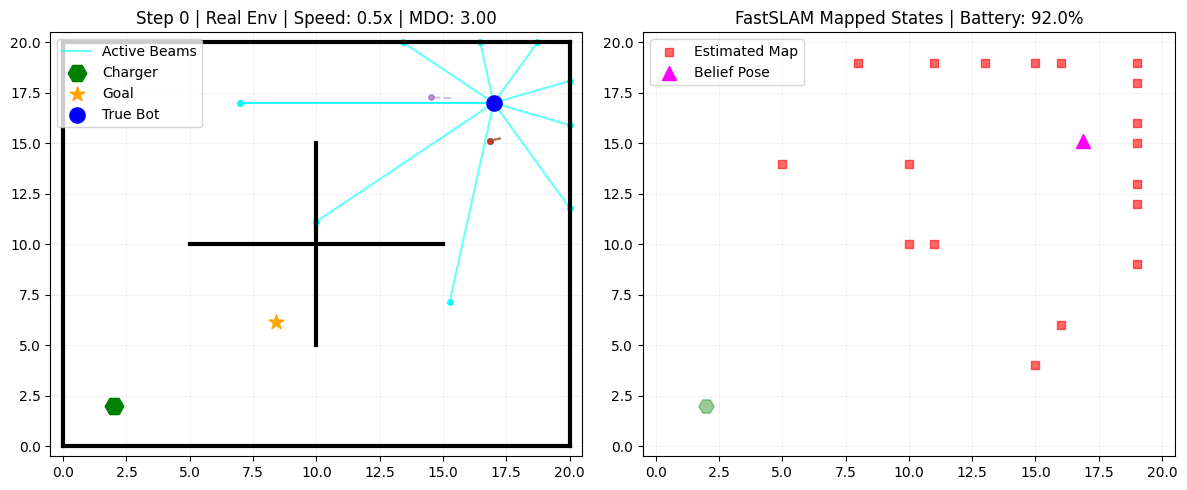

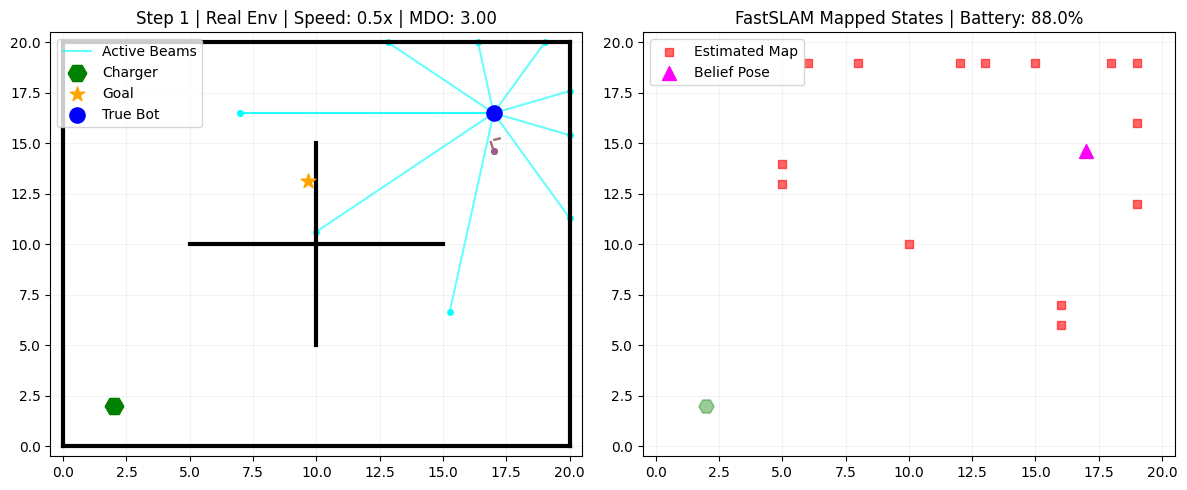

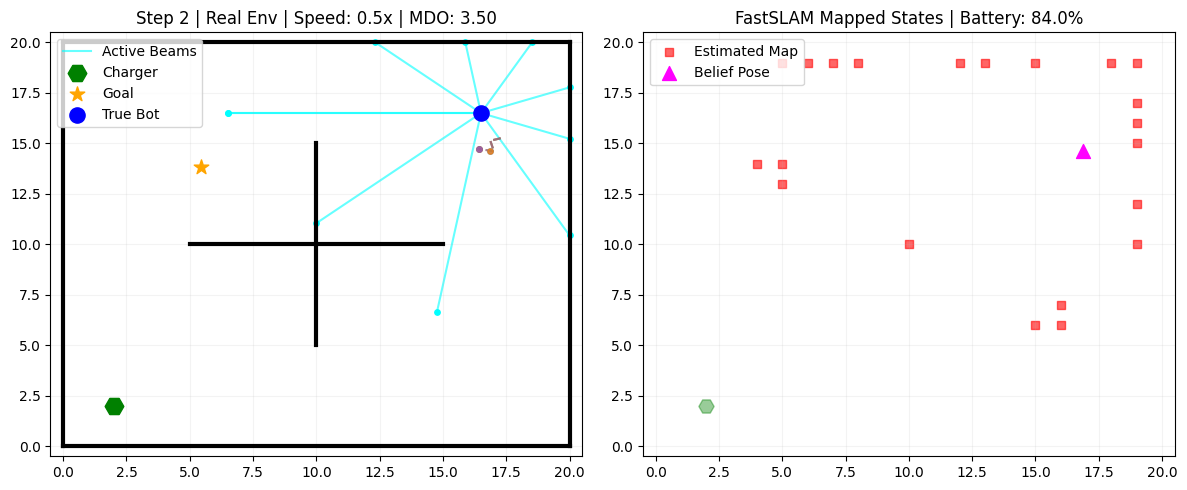

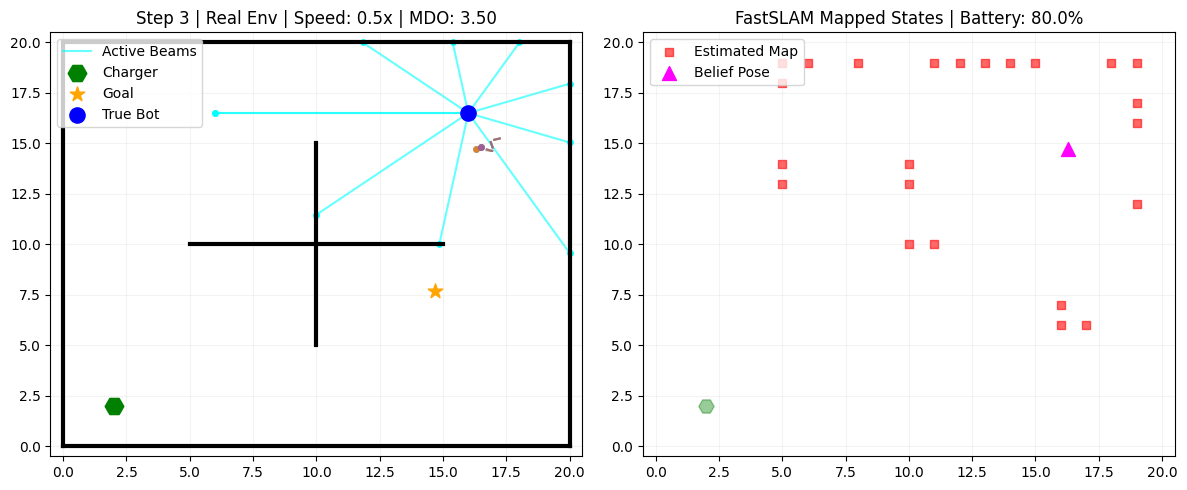

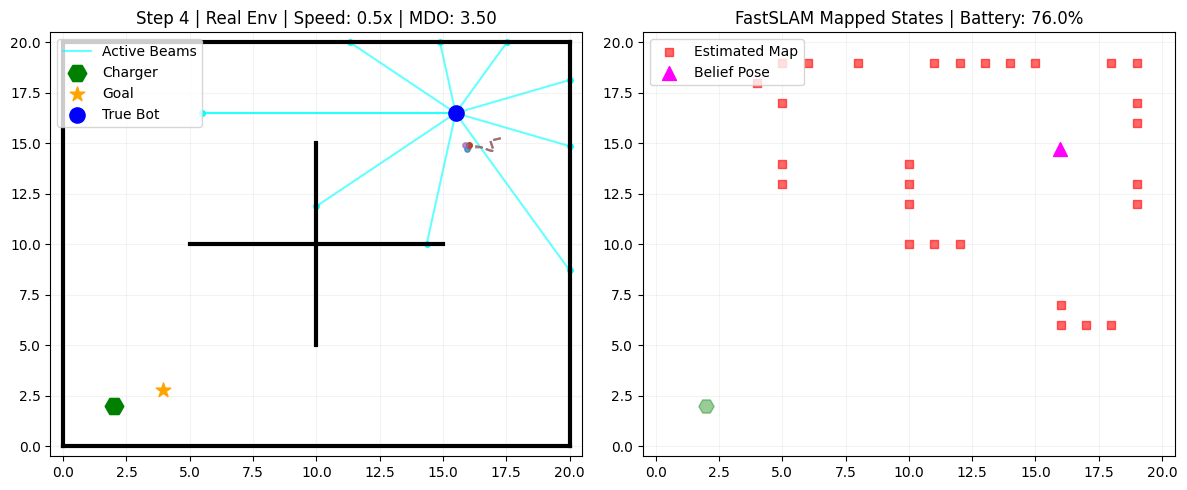

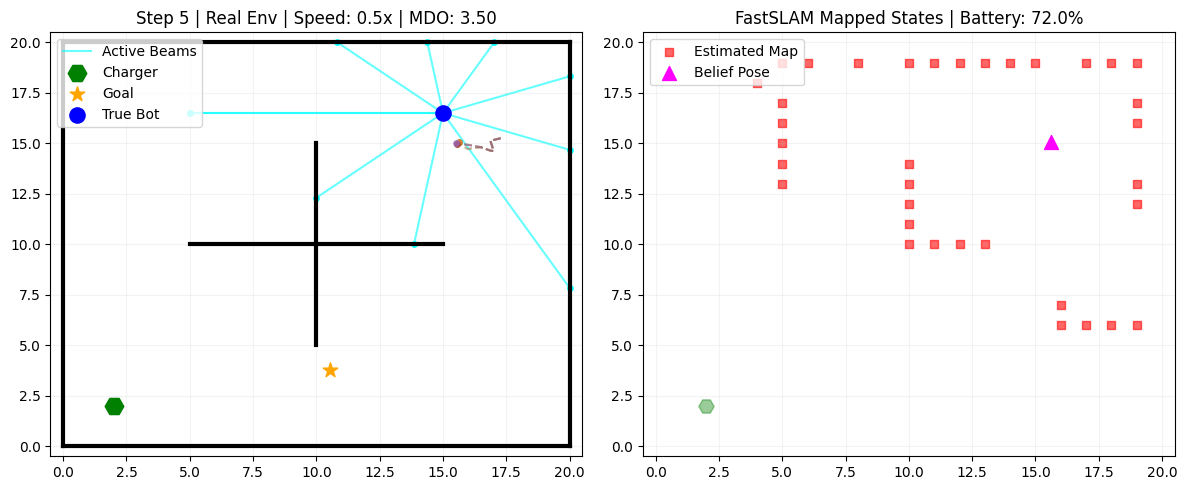

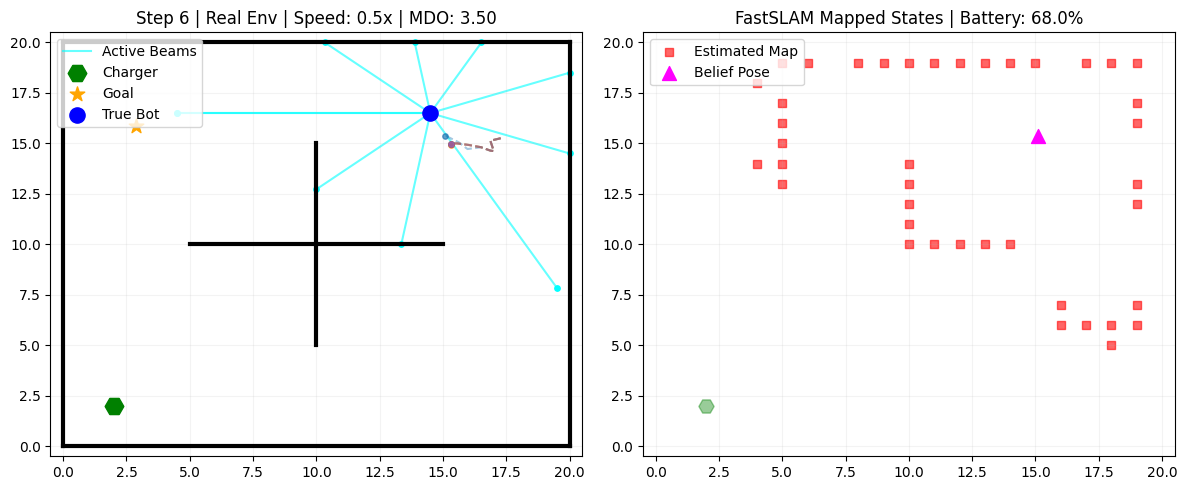

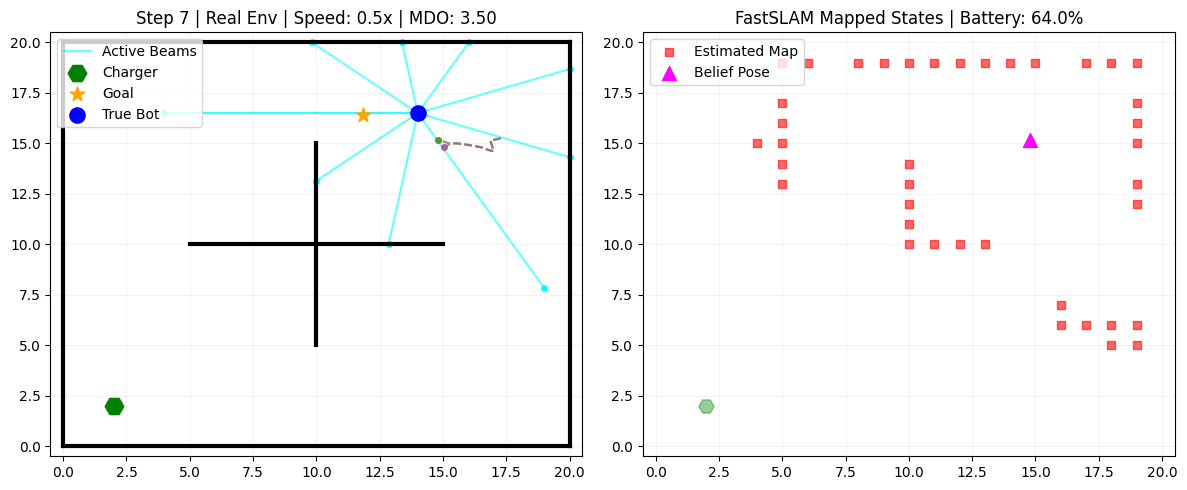

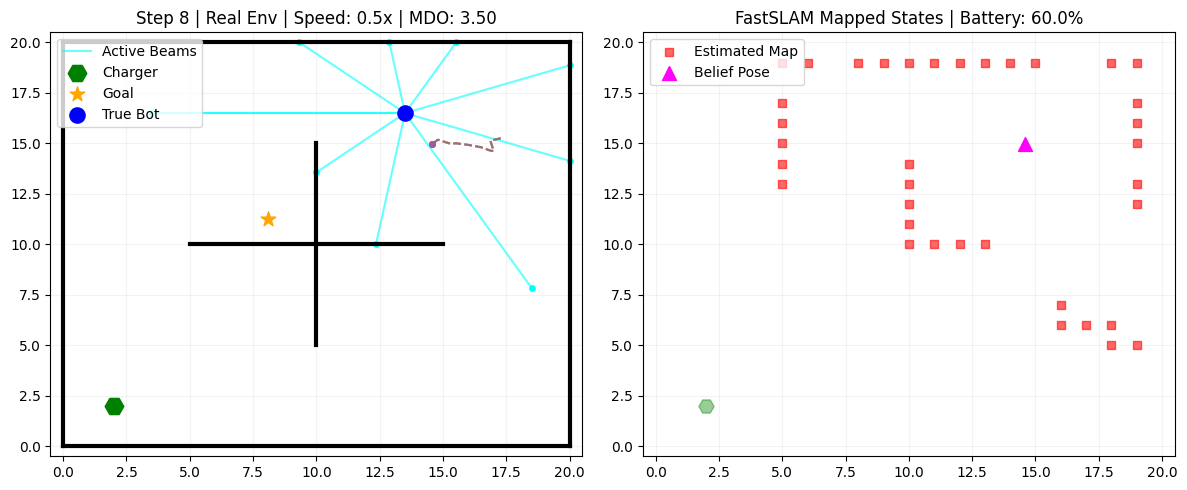

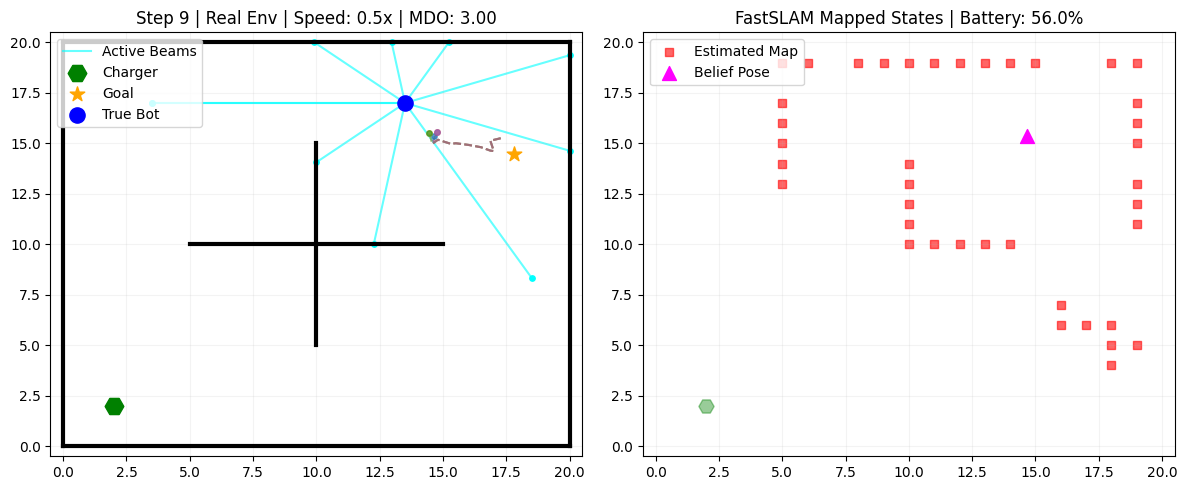

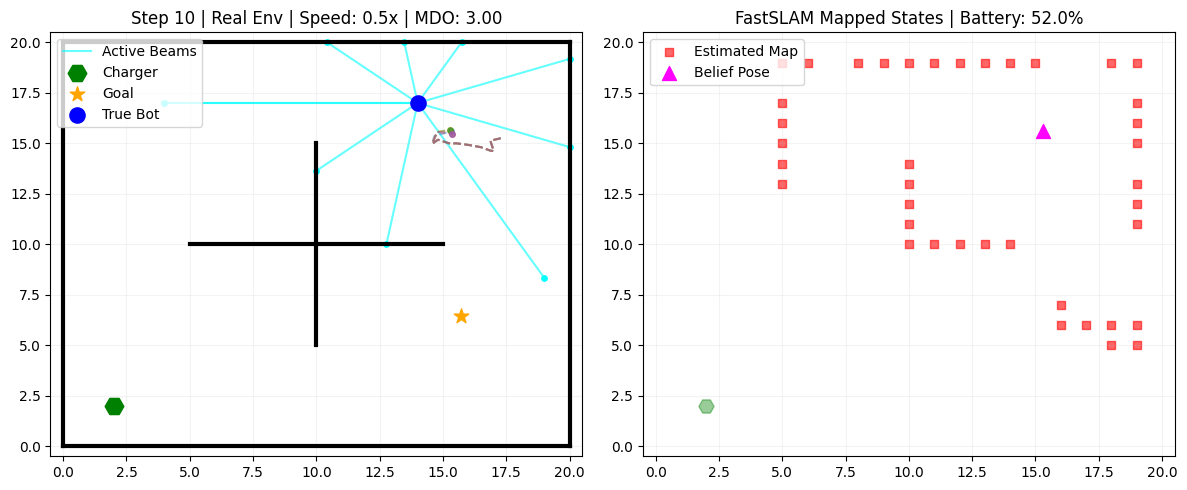

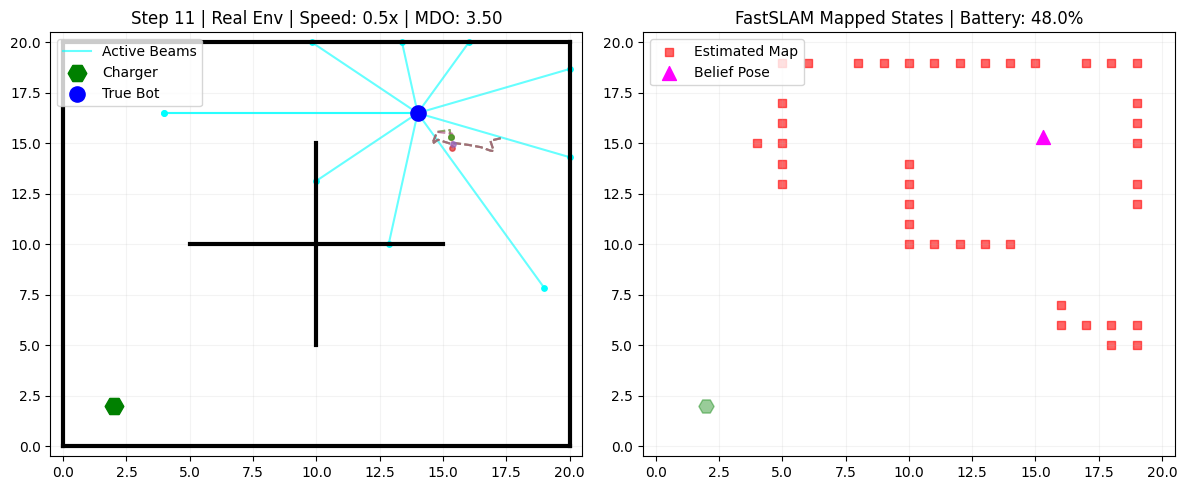

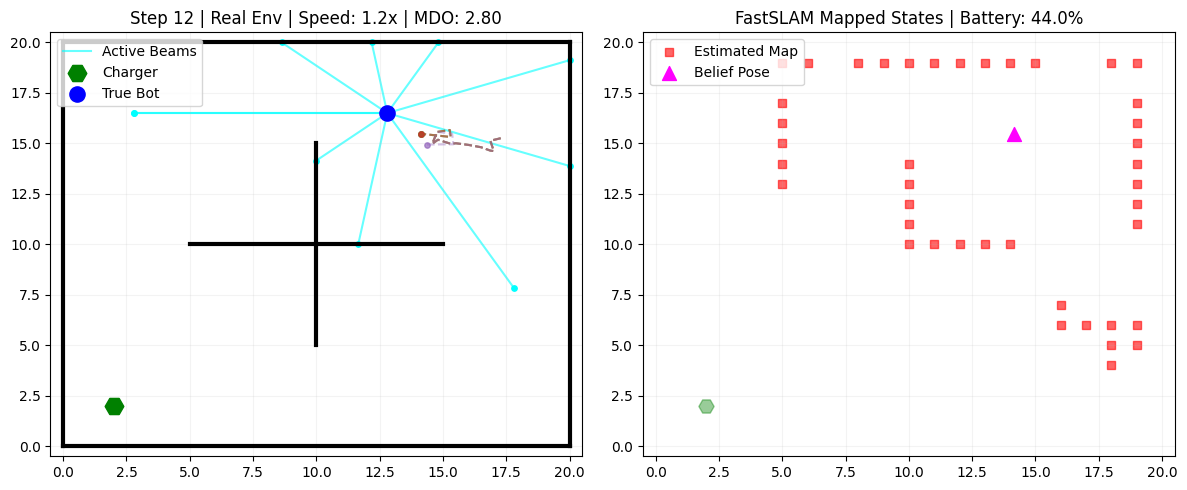

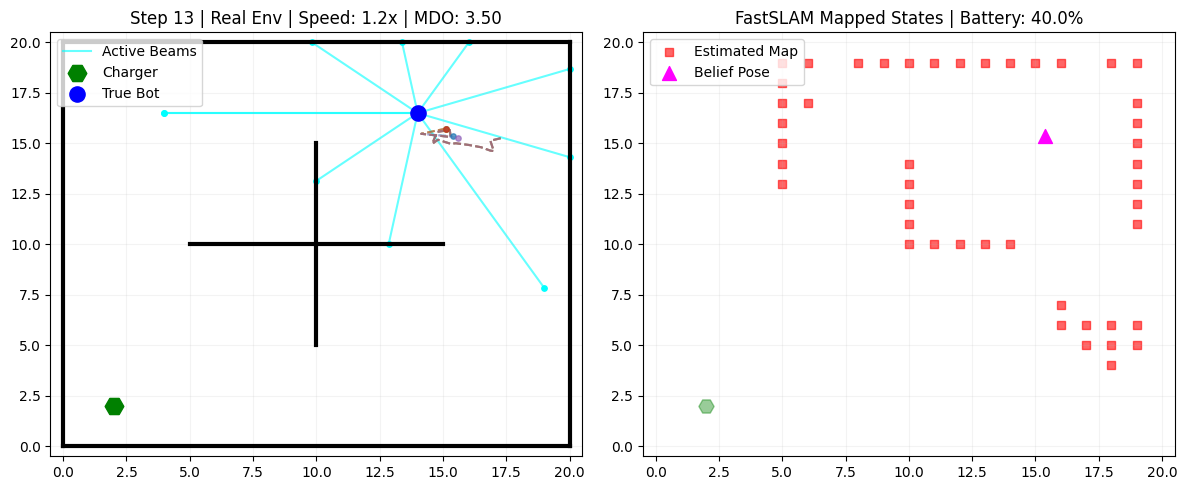

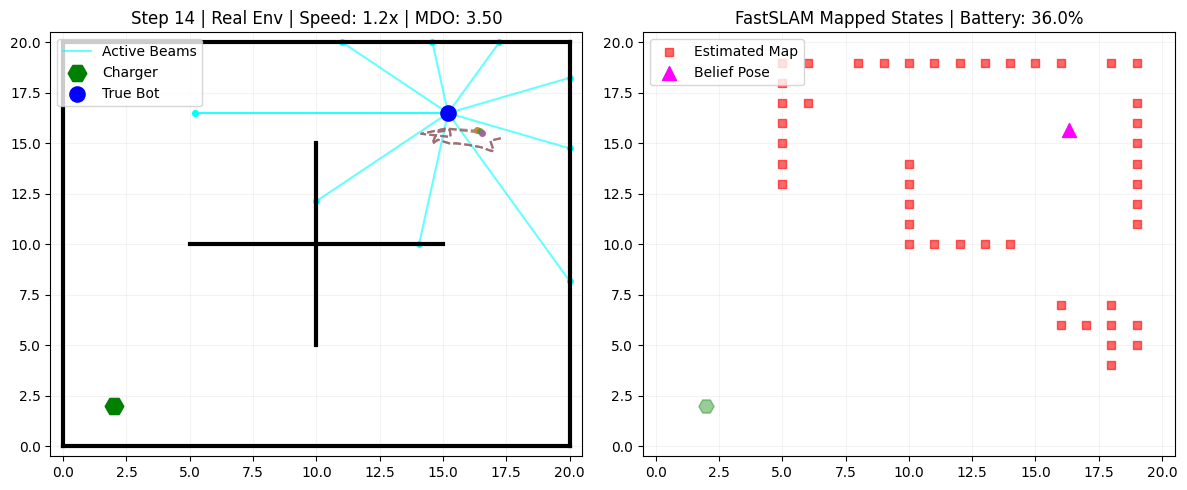

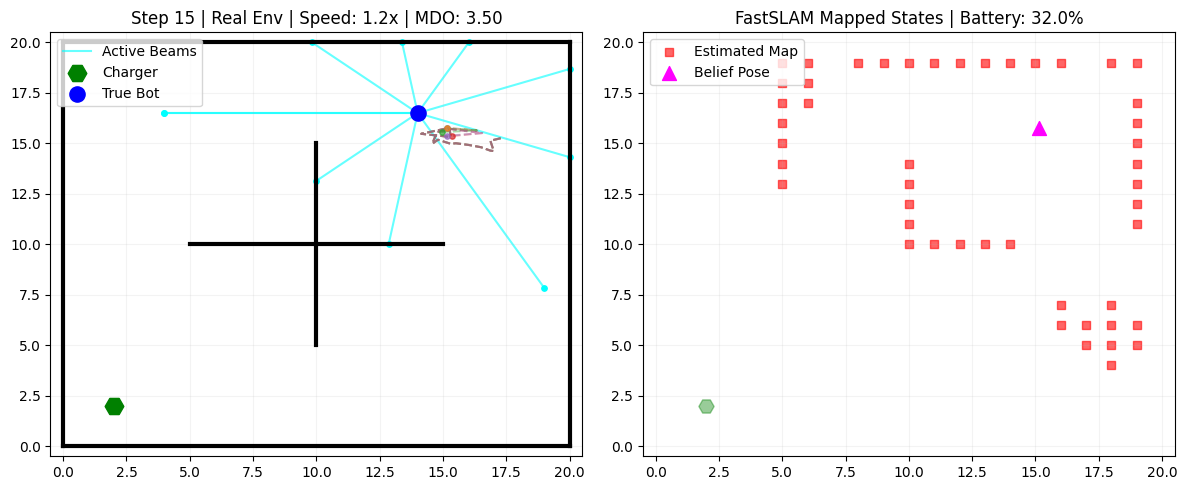

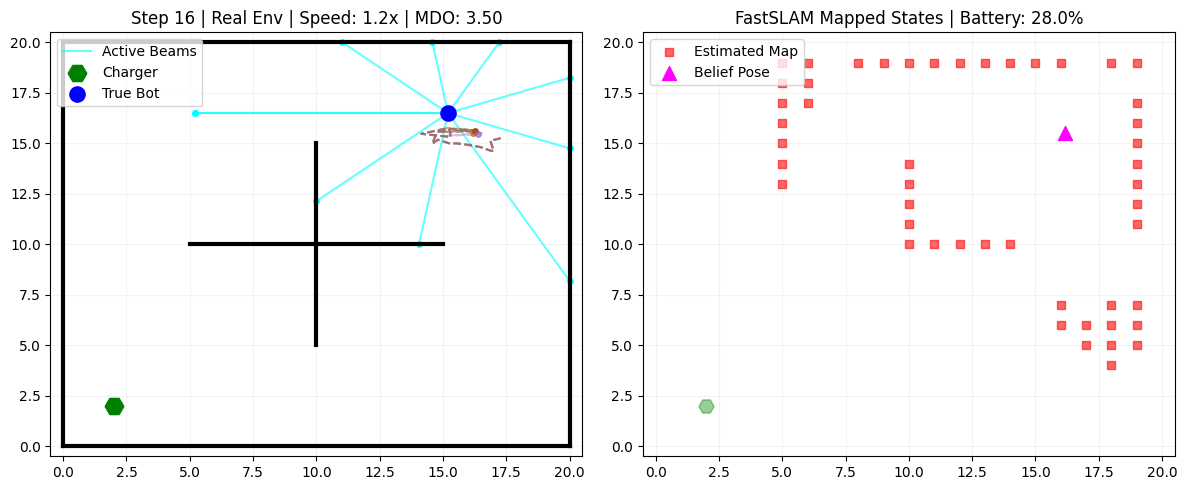

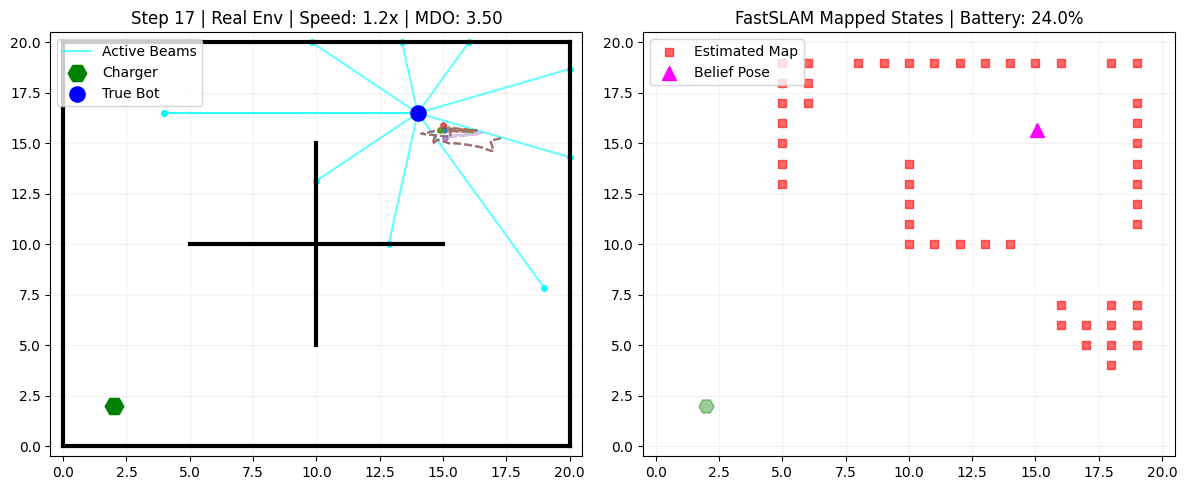

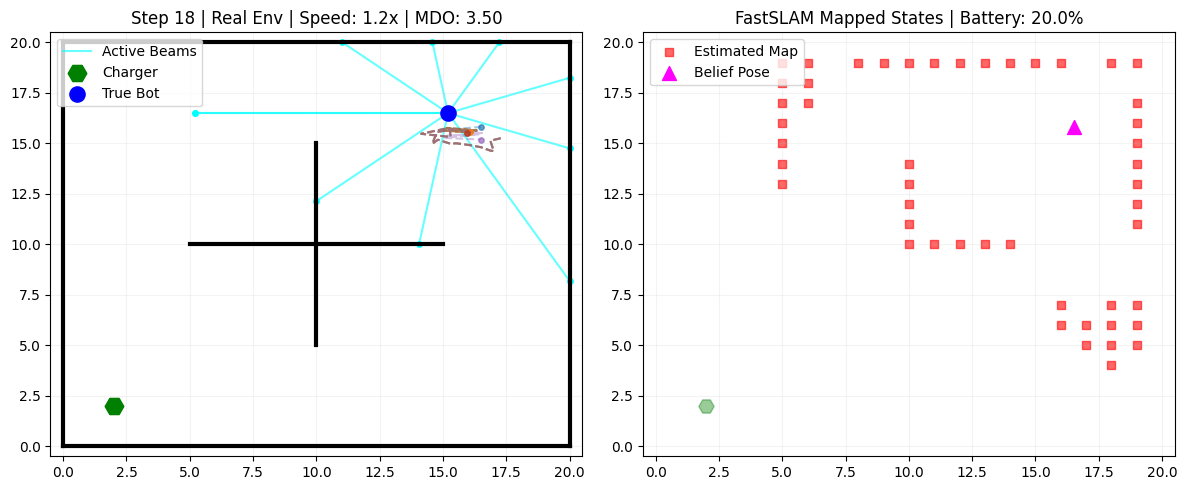

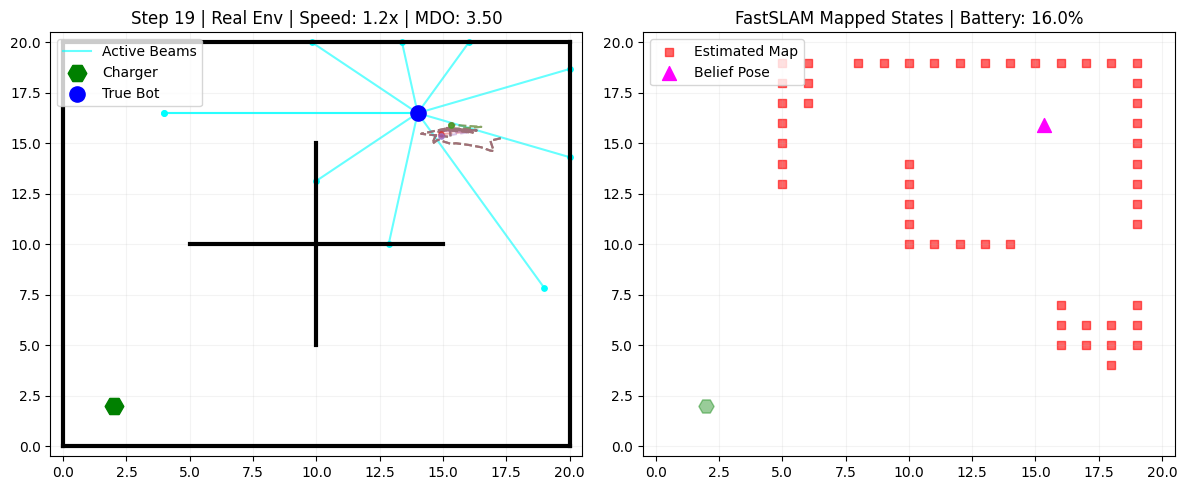

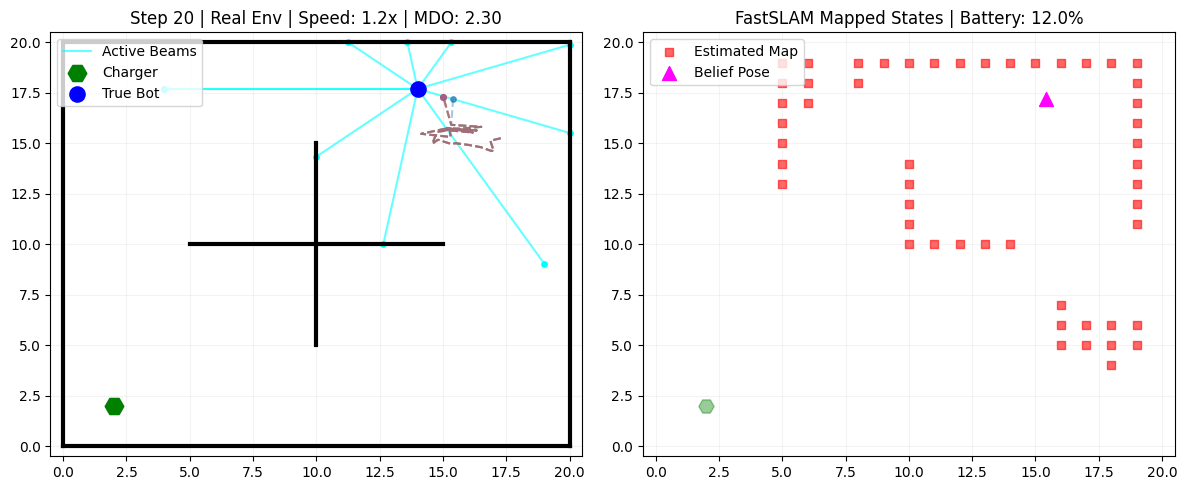

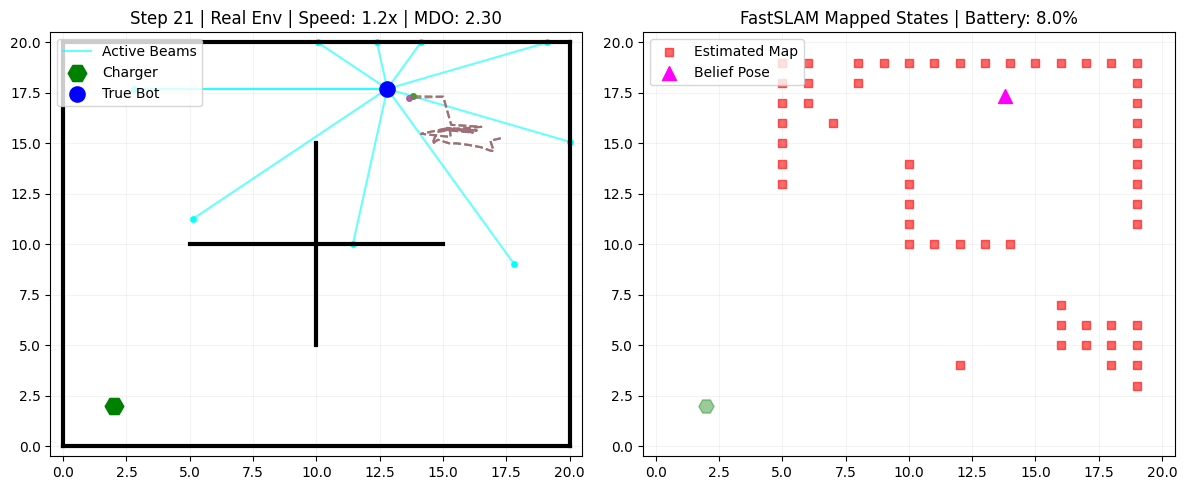

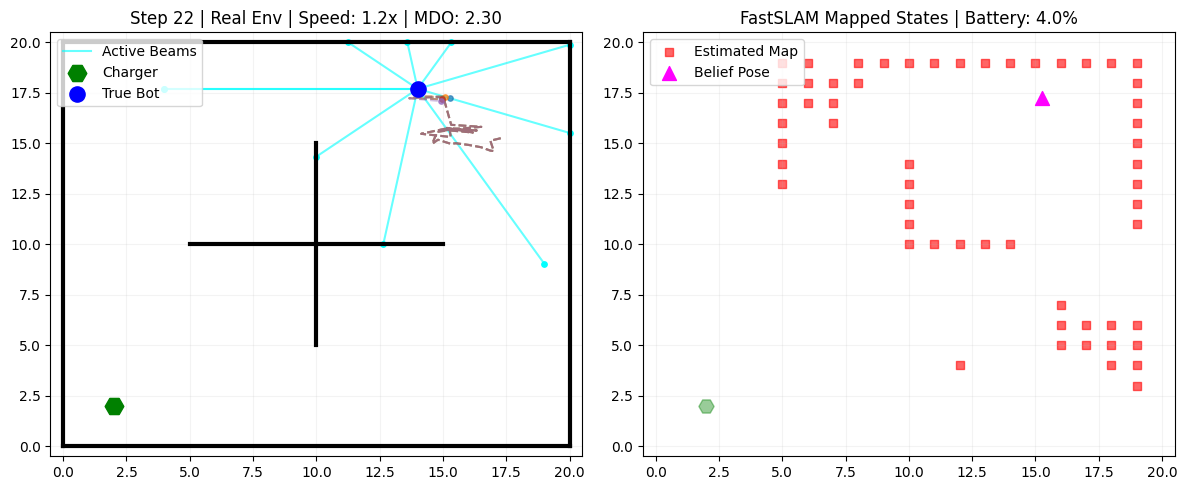

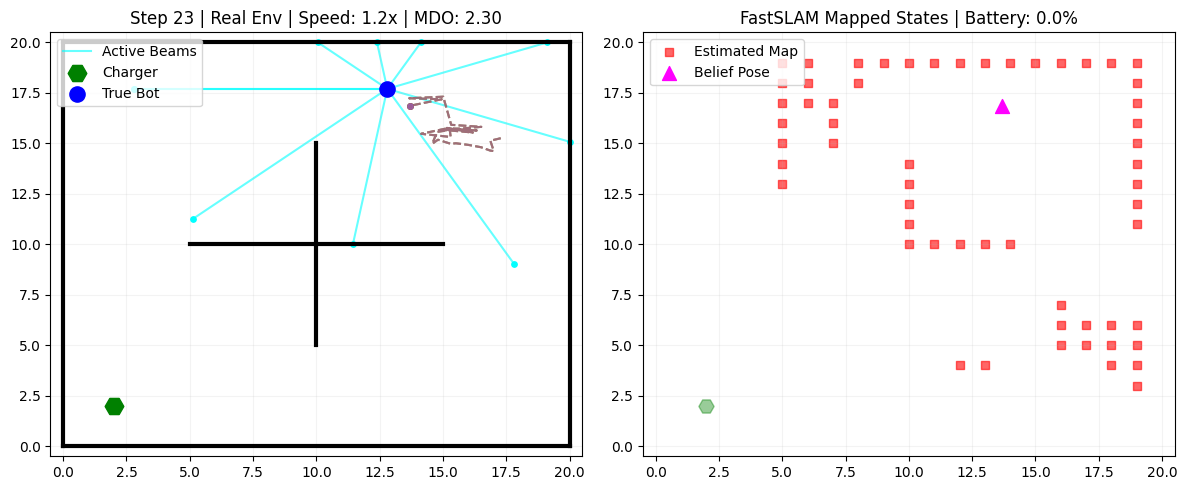

In [ ]:
def run_simulation():
    env = WarehouseEnv()
    agent = RLAgent()
    particles = [Particle() for _ in range(NUM_PARTICLES)]

    state, _, beams, hit_points, speed_mult = env.step(0)

    for step in range(200):
        action = agent.select_action(state, epsilon=0.1 if env.battery < BATTERY_THRESHOLD else 0.4)
        if env.battery <= 0.05:
          break
        state, reward, beams, hit_points, speed_mult = env.step(action)
        mdo_metric = env.calculate_collision_metric()

        # FastSLAM Filtering updates
        u = env.actions[action]
        weights = []
        for p in particles:
            p.predict(u, speed_mult)
            p.update(beams)
            weights.append(p.weight)

        # Resampling Logic
        weights = np.array(weights) + 1e-9
        weights /= np.sum(weights)
        indices = []
        r = random.uniform(0, 1.0 / NUM_PARTICLES)
        c = weights[0]
        i = 0
        for m in range(NUM_PARTICLES):
            u_val = r + m * (1.0 / NUM_PARTICLES)
            while u_val > c and i < NUM_PARTICLES - 1:
                i += 1
                c += weights[i]
            indices.append(i)

        new_particles = []
        for idx in indices:
            np_part = Particle()
            np_part.x = particles[idx].x.copy()
            np_part.history = list(particles[idx].history)
            np_part.map = particles[idx].map.copy()
            new_particles.append(np_part)
        particles = new_particles


        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.set_xlim(-0.5, GRID_SIZE + 0.5)
        ax1.set_ylim(-0.5, GRID_SIZE + 0.5)
        ax1.set_title(f"Step {step} | Real Env | Speed: {speed_mult}x | MDO: {mdo_metric:.2f}")


        for j, pt in enumerate(hit_points):
            b_label = "Active Beams" if j == 0 else ""
            ax1.plot([env.robot_pos[0], pt[0]], [env.robot_pos[1], pt[1]], color='cyan', alpha=0.6, zorder=1, label=b_label)
            ax1.scatter(pt[0], pt[1], color='cyan', marker='o', s=15, zorder=2)


        for wall in WALLS:
            ax1.plot([wall[0][0], wall[1][0]], [wall[0][1], wall[1][1]], color='black', linewidth=3, zorder=3)

        ax1.scatter(CHARGING_STATION[0], CHARGING_STATION[1], color='green', marker='H', s=180, label='Charger', zorder=4)
        if env.battery >= BATTERY_THRESHOLD:
            ax1.scatter(env.exploration_target[0], env.exploration_target[1], color='orange', marker='*', s=120, label='Goal', zorder=4)
        ax1.scatter(env.robot_pos[0], env.robot_pos[1], color='blue', s=120, zorder=5, label='True Bot')


        for p in particles:
            hist = np.array(p.history)
            ax1.plot(hist[:, 0], hist[:, 1], linestyle='--', alpha=0.4)
            ax1.scatter(p.x[0], p.x[1], marker='.', s=60, alpha=0.7, zorder=4)

        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.15)


        ax2.set_xlim(-0.5, GRID_SIZE + 0.5)
        ax2.set_ylim(-0.5, GRID_SIZE + 0.5)

        compiled_map = np.sum([p.map for p in particles], axis=0)
        y_indices, x_indices = np.where(compiled_map > 0)
        ax2.scatter(x_indices, y_indices, color='red', marker='s', s=40, alpha=0.6, label='Estimated Map')

        best_particle = particles[np.argmax([p.weight for p in particles])]
        ax2.scatter(best_particle.x[0], best_particle.x[1], color='magenta', marker='^', s=100, label='Belief Pose', zorder=5)
        ax2.scatter(CHARGING_STATION[0], CHARGING_STATION[1], color='green', marker='H', s=120, alpha=0.4)

        ax2.set_title(f"FastSLAM Mapped States | Battery: {env.battery:.1f}%")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.15)


        plt.tight_layout()
        plt.show()

run_simulation()